<a href="https://colab.research.google.com/github/krishna-gunda/Deep_Learning_concepts/blob/main/BinaryClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# now we are ready to built whole binary classsification using images

In [8]:
!unzip -FF /content/archive.zip -d /content/

Archive:  /content/archive.zip
  inflating: /content/test/not_pizza/3104030.jpg  
  inflating: /content/test/not_pizza/3108314.jpg  
  inflating: /content/test/not_pizza/3108421.jpg  
  inflating: /content/test/not_pizza/3123099.jpg  
  inflating: /content/test/not_pizza/3125420.jpg  
  inflating: /content/test/not_pizza/3130083.jpg  
  inflating: /content/test/not_pizza/3131740.jpg  
  inflating: /content/test/not_pizza/3139810.jpg  
  inflating: /content/test/not_pizza/3140015.jpg  
  inflating: /content/test/not_pizza/3140258.jpg  
  inflating: /content/test/not_pizza/3141241.jpg  
  inflating: /content/test/not_pizza/3146311.jpg  
  inflating: /content/test/not_pizza/3148100.jpg  
  inflating: /content/test/not_pizza/3148679.jpg  
  inflating: /content/test/not_pizza/3167676.jpg  
  inflating: /content/test/not_pizza/3176155.jpg  
  inflating: /content/test/not_pizza/3180423.jpg  
  inflating: /content/test/not_pizza/3181559.jpg  
  inflating: /content/test/not_pizza/3183638.jpg  


In [13]:
import os
len(os.listdir('/content/train/pizza'))

800

'val length'
  
   'not_pizza=183'

   'Pizza=183'

'train length'

   'not_pizza=800'

   'pizza= 800'

In [14]:
train_path='/content/train'
val_path='/content/val'

In [21]:
os.listdir('/content/val'+'/pizza')

['3486640.jpg',
 '3749515.jpg',
 '3713343.jpg',
 '3148119.jpg',
 '3629996.jpg',
 '3216107.jpg',
 '3770514.jpg',
 '3456604.jpg',
 '3882444.jpg',
 '2990186.jpg',
 '3628930.jpg',
 '3910117.jpg',
 '3430418.jpg',
 '3703769.jpg',
 '3385460.jpg',
 '3426946.jpg',
 '3550805.jpg',
 '3375083.jpg',
 '3798959.jpg',
 '3207504.jpg',
 '3039549.jpg',
 '3333459.jpg',
 '3512070.jpg',
 '3314535.jpg',
 '2997525.jpg',
 '3478964.jpg',
 '3441394.jpg',
 '3337370.jpg',
 '3653643.jpg',
 '3473991.jpg',
 '3830773.jpg',
 '3376519.jpg',
 '3314176.jpg',
 '3392194.jpg',
 '3669673.jpg',
 '3536393.jpg',
 '3614525.jpg',
 '3391208.jpg',
 '3814200.jpg',
 '3675128.jpg',
 '2999507.jpg',
 '3256974.jpg',
 '3803596.jpg',
 '3822139.jpg',
 '3784357.jpg',
 '3164761.jpg',
 '3772054.jpg',
 '3383977.jpg',
 '3049449.jpg',
 '3678290.jpg',
 '3392649.jpg',
 '3554287.jpg',
 '3724187.jpg',
 '3366256.jpg',
 '3020376.jpg',
 '3758160.jpg',
 '3109486.jpg',
 '3702863.jpg',
 '3342039.jpg',
 '3170114.jpg',
 '3296507.jpg',
 '3790235.jpg',
 '339389

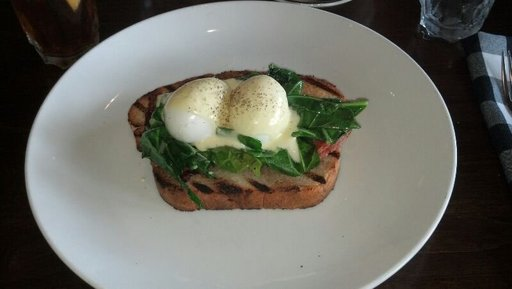

In [20]:
# whether the image is reading or not
# not_pizza image
import cv2
from google.colab.patches import cv2_imshow

image=cv2.imread('/content/val/not_pizza/3635304.jpg')
cv2_imshow(image)

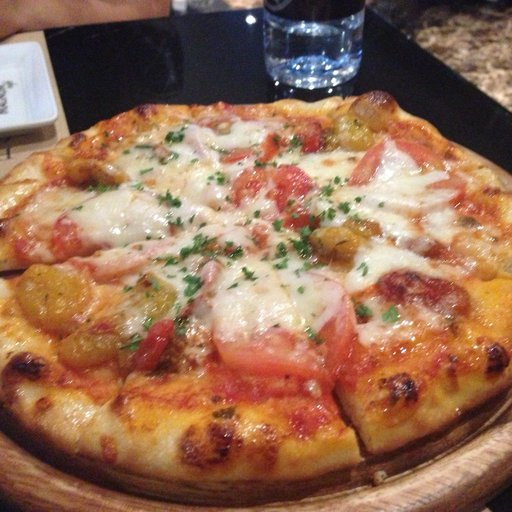

In [24]:
# pizza imaage
image=cv2.imread('/content/val/pizza/3557127.jpg')
cv2_imshow(image)

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [28]:
train_data_preprocesssing=ImageDataGenerator(1/255,rotation_range=0.2,shear_range=0.2,horizontal_flip=True)
val_data_preprocessing=ImageDataGenerator(1/255,rotation_range=0.2,shear_range=0.2,horizontal_flip=True)

In [30]:
labels=['not_pizza','pizza']

In [34]:
final_train=train_data_preprocesssing.flow_from_directory(train_path,target_size=(256,256),
                                                          class_mode='binary',classes= labels,
                                                          batch_size=20)
final_val=val_data_preprocessing.flow_from_directory(val_path,target_size=(256,256),
                                                          class_mode='binary',classes= labels)

Found 1600 images belonging to 2 classes.
Found 366 images belonging to 2 classes.


In [35]:
# Architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Activation
from tensorflow.keras.activations import relu,sigmoid,softmax


model = Sequential()

# 1st Hidden layer
model.add(Conv2D(filters=64 , kernel_size=(3,3),padding="valid",kernel_initializer="he_uniform",
                 activation=relu,))
model.add(MaxPool2D(pool_size=(2,2)))

# 2st Hidden layer
model.add(Conv2D(filters=16 , kernel_size=(3,3),padding="valid",kernel_initializer="he_uniform",
                 activation=relu,))
model.add(MaxPool2D(pool_size=(2,2)))

# 3rd Hidden layer
model.add(Conv2D(filters=4 , kernel_size=(3,3),padding="valid",kernel_initializer="he_uniform",
                 activation=relu,))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

# give to ann
model.add(Dense(units = 64 , kernel_initializer="he_uniform",activation=relu))
model.add(Dense(units = 16 , kernel_initializer="he_uniform",activation=relu))
model.add(Dense(units = 4 , kernel_initializer="he_uniform",activation=relu))

model.add(Dense(units = 1 , kernel_initializer="glorot_uniform",activation=sigmoid))

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer='adam',loss = 'binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(final_train , validation_data=final_val,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.4981 - loss: 0.8067 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/5
78/80 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 0.4825 - loss: 0.6932